# Importância das variáveis na configuração final

Qual a importância das variáveis nos cinco modelos selecionados da configuração final, normalizada como percentual do total de cada modelo, e quanto o ranqueamento muda em relação à configuração original.
Lê os pipelines já ajustados de `output/modelos_v2/`, a seleção de versões de `analysis/results_calibracao/selecao_base_vs_otimizada.csv` e as bases das duas configurações em `data/processed/`; a base de cálculo é o treino de 2020 a 2023, sobre o qual os modelos foram ajustados.
Produz as dez primeiras variáveis por modelo, a importância somada por variável da ficha, a comparação de ranqueamento entre as duas configurações e as razões de chances da Logistic Regression.
Nenhum modelo é treinado, calibrado ou reselecionado.

## Etapas
1. Reaplicar a seleção de versões do notebook 12, pela maior AUPRC na validação cruzada do treino.
2. Montar a partição de treino de 2020 a 2023 das duas configurações.
3. Declarar os rótulos em português dos preditores, seguindo a ficha de notificação do SINAN.
4. Extrair a importância nativa de cada modelo e normalizá-la como percentual do total.
5. Listar as dez primeiras variáveis de cada modelo, com a posição dos indicadores de bloco e das colunas que declaram ausente.
6. Somar a importância por variável da ficha, que é a leitura possível quando uma variável ocupa várias colunas da matriz de desenho.
7. Comparar as dez primeiras entre as duas configurações e medir a concordância por correlação de Spearman.
8. Confrontar as razões de chances da Logistic Regression com a importância SHAP normalizada.
9. Gravar as figuras de cinco e de três painéis.

## Entradas
- `output/modelos_v2/` (pipelines ajustados)
- `analysis/results_calibracao/selecao_base_vs_otimizada.csv`
- `data/processed/dengue_treated_corrigida.parquet`
- `data/processed/dengue_treated_antiga.parquet`

## Saídas
- `analysis/results_importancia/selecao_versao_por_algoritmo.csv`
- `analysis/results_importancia/bases_de_calculo.csv`
- `analysis/results_importancia/importancia_completa.csv`
- `analysis/results_importancia/top10_por_modelo_corrigida.csv`
- `analysis/results_importancia/indicadores_bloco_por_modelo.csv`
- `analysis/results_importancia/indicadores_ausente_por_modelo.csv`
- `analysis/results_importancia/importancia_agregada_por_variavel_origem.csv`
- `analysis/results_importancia/posicao_geografia_por_modelo.csv`
- `analysis/results_importancia/posicao_uf_por_modelo.csv`
- `analysis/results_importancia/comparacao_top10_antiga_corrigida.csv`
- `analysis/results_importancia/concordancia_spearman.csv`
- `analysis/results_importancia/razao_chances_regressao_logistica.csv`
- `analysis/plots/importancia/importancia_cinco_paineis.png`
- `analysis/plots/importancia/importancia_tres_paineis.png`

Importações, caminhos, constantes e formatadores em português.

In [1]:
import os
import sys
import textwrap
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Raiz do repositorio por marcador estavel, e nao por contagem de niveis:
# reorganizar as pastas de notebooks deixa de quebrar os caminhos.
def _raiz_repo(inicio=None):
    d = os.path.abspath(inicio or os.getcwd())
    while not any(os.path.exists(os.path.join(d, m)) for m in ('pyproject.toml', '.git')):
        pai = os.path.dirname(d)
        if pai == d:
            raise RuntimeError(f'raiz do repositorio nao encontrada acima de {os.getcwd()}')
        d = pai
    return d

ROOT = _raiz_repo()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from utils import configuracoes

PROC_DIR    = os.path.join(ROOT, 'data', 'processed')
DIR_MODELOS = os.path.join(ROOT, 'output', 'modelos_v2')
DIR_RES_CAL = os.path.join(ROOT, 'analysis', 'results_calibracao')
DIR_TABELAS = os.path.join(ROOT, 'analysis', 'results_importancia')
DIR_FIGURAS = os.path.join(ROOT, 'analysis', 'plots', 'importancia')
for _d in (DIR_TABELAS, DIR_FIGURAS):
    os.makedirs(_d, exist_ok=True)

RANDOM_STATE = 42
CALIBRACAO   = 'Platt'
REGRA_LIMIAR = 'sensibilidade 0,80 no treino'
ANOS_TREINO  = [2020, 2021, 2022, 2023]
TOP_N        = 10

CONFIG_PRINCIPAL  = 'corrigida'
CONFIG_COMPARACAO = 'antiga'
CONFIGS = [CONFIG_COMPARACAO, CONFIG_PRINCIPAL]
# Chave interna -> rotulo publicado. As chaves nomeiam arquivos e nao mudam.
ROTULO_CONFIG = {'antiga': 'original', 'corrigida': 'final'}
# Ordem de exibicao pela chave, e nao pelo texto do rotulo.
ORDEM_CONFIG = {ROTULO_CONFIG[c]: i for i, c in enumerate(CONFIGS)}
SUFIXO_VERSAO = {'base': '', 'otimizada': '_tuned'}

ALGORITMOS = {
    'logistic_regression': 'Regressão Logística',
    'decision_tree':       'Árvore de Decisão',
    'random_forest':       'Random Forest',
    'xgboost':             'XGBoost',
    'lightgbm':            'LightGBM',
}
ORDEM_ALGO = {r: i for i, r in enumerate(ALGORITMOS.values())}

# Medida nativa de cada família, na forma em que o próprio modelo a expõe.
MEDIDA = {
    'logistic_regression': 'SHAP médio absoluto',
    'decision_tree':       'redução média de impureza (Gini)',
    'random_forest':       'redução média de impureza (Gini)',
    'xgboost':             'ganho',
    'lightgbm':            'ganho',
}

INDICADORES_BLOCO = list(configuracoes.BLOCO_COLS)

# Paleta de destaque: a cor tem um único papel na figura, marcar os indicadores de
# bloco. O nome do modelo fica no título de cada painel, então a cor não precisa
# identificar algoritmo. O rótulo em negrito repete o destaque sem depender da cor.
COR_DESTAQUE = '#eb6834'
COR_DEMAIS   = '#8a8985'
COR_TINTA    = '#52514e'

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 9, 'axes.titlesize': 11, 'axes.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c3', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'text.color': '#0b0b0b',
    'grid.color': '#e8e7e3', 'grid.linewidth': 0.8,
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff', 'legend.frameon': False,
})


def n_(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return '-'
    return f'{int(x):,}'.replace(',', '.')


def v_(x, casas=3):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return '-'
    return f'{x:.{casas}f}'.replace('.', ',')


def pct_(x, casas=1):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return '-'
    return f'{x:.{casas}f}'.replace('.', ',') + '%'


def ic_(lo, hi, casas=2):
    return f'[{v_(lo, casas)}; {v_(hi, casas)}]'


def par_(texto, largura=96):
    return textwrap.fill(' '.join(texto.split()), largura)


def eixo_pct(casas=0):
    return mpl.ticker.FuncFormatter(
        lambda x, pos=None: f'{x:.{casas}f}'.replace('.', ',') + '%')


def salvar_tab(df, nome, index=False):
    caminho = os.path.join(DIR_TABELAS, nome)
    df.to_csv(caminho, index=index, encoding='utf-8')
    print(f'[tabela] {os.path.relpath(caminho, ROOT)}  ({len(df)} linhas)')
    return df


def salvar_fig(fig, nome):
    caminho = os.path.join(DIR_FIGURAS, nome)
    fig.savefig(caminho, dpi=300, bbox_inches='tight', facecolor='#ffffff')
    print(f'[figura] {os.path.relpath(caminho, ROOT)}')


print(f'Configuração principal: {ROTULO_CONFIG[CONFIG_PRINCIPAL]} · '
      f'comparação: {ROTULO_CONFIG[CONFIG_COMPARACAO]}')
print(f'Medidas: {", ".join(sorted(set(MEDIDA.values())))}')
print(f'Normalização: percentual do total de cada modelo · semente {RANDOM_STATE}')

Configuração principal: final · comparação: original
Medidas: SHAP médio absoluto, ganho, redução média de impureza (Gini)
Normalização: percentual do total de cada modelo · semente 42


Reaplica a seleção do notebook 12: em cada par base/otimizada fica a versão de maior AUPRC na validação cruzada do treino, com empate exato indo para a base.

In [2]:
df_sel_bruta = pd.read_csv(os.path.join(DIR_RES_CAL, 'selecao_base_vs_otimizada.csv'))
df_sel_bruta = df_sel_bruta[(df_sel_bruta['calibracao'] == CALIBRACAO)
                            & (df_sel_bruta['regra_limiar'] == REGRA_LIMIAR)]

linhas = []
for cfg in CONFIGS:
    for algo, rotulo in ALGORITMOS.items():
        r = df_sel_bruta[(df_sel_bruta['algoritmo'] == rotulo)
                         & (df_sel_bruta['configuracao'] == ROTULO_CONFIG[cfg])].iloc[0]
        base, otim = float(r['auprc_vc_treino_base']), float(r['auprc_vc_treino_otimizada'])
        # Empate exato vai para a base, por parcimônia, como no notebook 12.
        versao = 'otimizada' if otim > base else 'base'
        linhas.append({
            'algoritmo': rotulo, 'configuracao': ROTULO_CONFIG[cfg],
            'versao_selecionada': versao,
            'auprc_vc_treino_base': round(base, 4),
            'auprc_vc_treino_otimizada': round(otim, 4),
            'auprc_vc_treino_selecionada': round(max(base, otim), 4),
            'medida_importancia': MEDIDA[algo],
            'n_base_treino': int(r['n_base_treino']),
            'eventos_treino': int(r['eventos_treino']),
        })

df_selecao = pd.DataFrame(linhas)
df_selecao['_a'] = df_selecao['algoritmo'].map(ORDEM_ALGO)
df_selecao['_c'] = df_selecao['configuracao'].map(ORDEM_CONFIG)
df_selecao = (df_selecao.sort_values(['_c', '_a'])
              .drop(columns=['_c', '_a']).reset_index(drop=True))
salvar_tab(df_selecao, 'selecao_versao_por_algoritmo.csv')

VERSAO_SELECIONADA = {(r['configuracao'], r['algoritmo']): r['versao_selecionada']
                      for _, r in df_selecao.iterrows()}

# A seleção da configuração corrigida é a do notebook 12: confere-se contra a tabela
# que ele gravou, em vez de repetir aqui uma lista fixa de versões.
ref = pd.read_csv(os.path.join(ROOT, 'analysis', 'results_equidade',
                               'selecao_versao_por_algoritmo.csv'))
ref = ref[ref['configuracao'] == ROTULO_CONFIG[CONFIG_PRINCIPAL]]
for _, r in ref.iterrows():
    assert VERSAO_SELECIONADA[(r['configuracao'], r['algoritmo'])] == r['versao_selecionada'], (
        f'{r["algoritmo"]}: {VERSAO_SELECIONADA[(r["configuracao"], r["algoritmo"])]} aqui, '
        f'{r["versao_selecionada"]} no notebook 12')
print(f'Seleção conferida contra o notebook 12 nos {len(ref)} algoritmos da configuração '
      f'{ROTULO_CONFIG[CONFIG_PRINCIPAL]}.')

display(df_selecao.drop(columns=['n_base_treino', 'eventos_treino']))

[tabela] analysis/results_importancia/selecao_versao_por_algoritmo.csv  (10 linhas)
Seleção conferida contra o notebook 12 nos 5 algoritmos da configuração final.


,algoritmo,configuracao,versao_selecionada,auprc_vc_treino_base,auprc_vc_treino_otimizada,auprc_vc_treino_selecionada,medida_importancia
0,Regressão Logística,original,otimizada,0.6239,0.6242,0.6242,SHAP médio absoluto
1,Árvore de Decisão,original,otimizada,0.5492,0.5710,0.5710,redução média de impureza (Gini)
2,Random Forest,original,otimizada,0.6397,0.6415,0.6415,redução média de impureza (Gini)
3,XGBoost,original,otimizada,0.6216,0.6485,0.6485,ganho
4,LightGBM,original,otimizada,0.6242,0.6404,0.6404,ganho
5,Regressão Logística,final,otimizada,0.6346,0.6347,0.6347,SHAP médio absoluto
6,Árvore de Decisão,final,otimizada,0.5730,0.6207,0.6207,redução média de impureza (Gini)
7,Random Forest,final,otimizada,0.6527,0.6530,0.6530,redução média de impureza (Gini)
8,XGBoost,final,otimizada,0.6298,0.6556,0.6556,ganho
9,LightGBM,final,otimizada,0.6304,0.6477,0.6477,ganho


Monta a partição de treino de 2020 a 2023 das duas configurações, que é a base sobre a qual os cinco modelos foram ajustados.

In [3]:
particoes, linhas = {}, []
for cfg in CONFIGS:
    df = pd.read_parquet(os.path.join(PROC_DIR, f'dengue_treated_{cfg}.parquet'),
                         engine='pyarrow')
    preds = configuracoes.preditores(cfg)
    m = df['year'].isin(ANOS_TREINO) & df['target'].notna()
    X = df.loc[m, preds].reset_index(drop=True)
    y = df.loc[m, 'target'].astype(int).to_numpy()
    particoes[cfg] = {'X': X, 'y': y}
    linhas.append({
        'configuracao': ROTULO_CONFIG[cfg], 'particao': 'treino',
        'anos': '-'.join(str(a) for a in ANOS_TREINO),
        'n_preditores': len(preds), 'n_base': len(X), 'eventos': int(y.sum()),
        'prevalencia_pct': round(float(y.mean()) * 100, 2),
    })

# As duas bases vêm da mesma coorte: o treino tem de ser linha a linha o mesmo.
Y_TREINO = particoes[CONFIG_PRINCIPAL]['y']
for cfg in CONFIGS:
    assert np.array_equal(particoes[cfg]['y'], Y_TREINO), f'{cfg}: treino desalinhado'

N_TREINO, EVENTOS_TREINO = len(Y_TREINO), int(Y_TREINO.sum())

df_bases = pd.DataFrame(linhas)
salvar_tab(df_bases, 'bases_de_calculo.csv')
display(df_bases)
print(f'\nBase de cálculo: {n_(N_TREINO)} internações e {n_(EVENTOS_TREINO)} óbitos')

[tabela] analysis/results_importancia/bases_de_calculo.csv  (2 linhas)


,configuracao,particao,anos,n_preditores,n_base,eventos,prevalencia_pct
0,original,treino,2020-2021-2022-2023,51,127074,2624,2.06
1,final,treino,2020-2021-2022-2023,53,127074,2624,2.06



Base de cálculo: 127.074 internações e 2.624 óbitos


Rótulos em português dos preditores, seguindo a ficha de notificação do SINAN.

In [4]:
ROTULO_VARIAVEL = {
    # Demográficos e derivados
    'age_years':   'Idade',
    'epi_week':    'Semana epidemiológica',
    'CS_SEXO':     'Sexo',
    'CS_ESCOL_N':  'Escolaridade',
    'SG_UF':       'UF de residência',
    'CS_RACA':     'Raça/cor',
    'CS_GESTANT':  'Gestação',
    'CS_RACA_1.0': 'Raça/cor: branca',
    'CS_RACA_2.0': 'Raça/cor: preta',
    'CS_RACA_3.0': 'Raça/cor: amarela',
    'CS_RACA_4.0': 'Raça/cor: parda',
    'CS_RACA_5.0': 'Raça/cor: indígena',
    'CS_GESTANT_1.0': 'Gestação: 1º trimestre',
    'CS_GESTANT_2.0': 'Gestação: 2º trimestre',
    'CS_GESTANT_3.0': 'Gestação: 3º trimestre',
    'CS_GESTANT_4.0': 'Gestação: IG ignorada',
    'CS_GESTANT_5.0': 'Não gestante',
    'CS_GESTANT_6.0': 'Gestação: não se aplica',
    'escolaridade_nao_se_aplica': 'Escolaridade: não se aplica',
    # Macrorregião em one-hot nas configurações corrigida e notificação; na antiga a UF é
    # uma única coluna ordinal, e as 27 abaixo não existem.
    'SG_UF_11': 'UF: Rondônia',
    'SG_UF_12': 'UF: Acre',
    'SG_UF_13': 'UF: Amazonas',
    'SG_UF_14': 'UF: Roraima',
    'SG_UF_15': 'UF: Pará',
    'SG_UF_16': 'UF: Amapá',
    'SG_UF_17': 'UF: Tocantins',
    'SG_UF_21': 'UF: Maranhão',
    'SG_UF_22': 'UF: Piauí',
    'SG_UF_23': 'UF: Ceará',
    'SG_UF_24': 'UF: Rio Grande do Norte',
    'SG_UF_25': 'UF: Paraíba',
    'SG_UF_26': 'UF: Pernambuco',
    'SG_UF_27': 'UF: Alagoas',
    'SG_UF_28': 'UF: Sergipe',
    'SG_UF_29': 'UF: Bahia',
    'SG_UF_31': 'UF: Minas Gerais',
    'SG_UF_32': 'UF: Espírito Santo',
    'SG_UF_33': 'UF: Rio de Janeiro',
    'SG_UF_35': 'UF: São Paulo',
    'SG_UF_41': 'UF: Paraná',
    'SG_UF_42': 'UF: Santa Catarina',
    'SG_UF_43': 'UF: Rio Grande do Sul',
    'SG_UF_50': 'UF: Mato Grosso do Sul',
    'SG_UF_51': 'UF: Mato Grosso',
    'SG_UF_52': 'UF: Goiás',
    'SG_UF_53': 'UF: Distrito Federal',
    # Macrorregião substitui a UF nas configurações corrigida e notificação.
    'macrorregiao':              'Macrorregião de residência',
    'macrorregiao_Norte':        'Macrorregião: Norte',
    'macrorregiao_Nordeste':     'Macrorregião: Nordeste',
    'macrorregiao_Sudeste':      'Macrorregião: Sudeste',
    'macrorregiao_Sul':          'Macrorregião: Sul',
    'macrorregiao_Centro-Oeste': 'Macrorregião: Centro-Oeste',
    # Ausente como nível próprio do codificador, nas configurações corrigida e notificação.
    'CS_RACA_nan':          'Raça/cor: não informada',
    'CS_GESTANT_nan':       'Gestação: não informada',
    'escolaridade_ausente': 'Escolaridade não informada',
    # Só a família linear a recebe: onde o NaN é nativo o algoritmo já separa o ausente.
    'sexo_ausente':         'Sexo não informado',
    # Sintomas e comorbidades
    'FEBRE':      'Febre',                 'MIALGIA':    'Mialgia',
    'CEFALEIA':   'Cefaleia',              'EXANTEMA':   'Exantema',
    'VOMITO':     'Vômito',                'NAUSEA':     'Náusea',
    'DOR_COSTAS': 'Dor nas costas',        'CONJUNTVIT': 'Conjuntivite',
    'ARTRITE':    'Artrite',               'ARTRALGIA':  'Artralgia',
    'PETEQUIA_N': 'Petéquias',             'LEUCOPENIA': 'Leucopenia',
    'LACO':       'Prova do laço',         'DOR_RETRO':  'Dor retro-orbital',
    'DIABETES':   'Diabetes',              'HEMATOLOG':  'Doença hematológica',
    'HEPATOPAT':  'Hepatopatia',           'RENAL':      'Doença renal',
    'HIPERTENSA': 'Hipertensão (comorbidade)', 'AUTO_IMUNE': 'Doença autoimune',
    # Sinais de alarme
    'ALRM_HIPOT': 'Hipotensão postural',   'ALRM_PLAQ':  'Queda abrupta de plaquetas',
    'ALRM_VOM':   'Vômitos persistentes',  'ALRM_SANG':  'Sangramento de mucosa',
    'ALRM_HEMAT': 'Aumento do hematócrito', 'ALRM_ABDOM': 'Dor abdominal contínua',
    'ALRM_LETAR': 'Letargia ou irritabilidade', 'ALRM_HEPAT': 'Hepatomegalia',
    'ALRM_LIQ':   'Acúmulo de líquidos',
    # Manifestações graves
    'GRAV_PULSO': 'Pulso débil',           'GRAV_CONV':  'Convulsão',
    'GRAV_ENCH':  'Enchimento capilar lento', 'GRAV_INSUF': 'Insuficiência respiratória',
    'GRAV_TAQUI': 'Taquicardia',           'GRAV_EXTRE': 'Extremidades frias',
    'GRAV_HIPOT': 'Hipotensão arterial',   'GRAV_HEMAT': 'Hematêmese',
    'GRAV_MELEN': 'Melena',                'GRAV_METRO': 'Metrorragia volumosa',
    'GRAV_SANG':  'Sangramento no SNC',    'GRAV_AST':   'AST/ALT acima de 1.000',
    'GRAV_MIOC':  'Miocardite',            'GRAV_CONSC': 'Alteração da consciência',
    'GRAV_ORGAO': 'Disfunção de órgãos',
    # Indicadores de bloco
    'bloco_alarme_avaliado':    'Bloco de alarme avaliado',
    'bloco_gravidade_avaliado': 'Bloco de gravidade avaliado',
}

BLOCO_DE = {}
for _c in configuracoes.SINTOMAS:
    BLOCO_DE[_c] = 'sintoma ou comorbidade'
for _c in configuracoes.ALRM_COLS:
    BLOCO_DE[_c] = 'sinal de alarme'
for _c in configuracoes.GRAV_COLS:
    BLOCO_DE[_c] = 'manifestação grave'
for _c in configuracoes.DEMOGRAFICOS:
    BLOCO_DE[_c] = 'demográfico'
for _c in configuracoes.DERIVADOS:
    BLOCO_DE[_c] = 'derivado'
for _c in INDICADORES_BLOCO:
    BLOCO_DE[_c] = 'indicador de bloco'
BLOCO_DE['escolaridade_nao_se_aplica'] = 'demográfico'
BLOCO_DE['escolaridade_ausente'] = 'demográfico'
BLOCO_DE['sexo_ausente'] = 'demográfico'
BLOCO_DE[configuracoes.COL_MACRORREGIAO] = 'demográfico'


def rotular(variavel):
    return ROTULO_VARIAVEL.get(variavel, variavel)


def bloco_de(variavel):
    '''Bloco da variável original: as colunas de one-hot herdam o bloco da origem.'''
    return BLOCO_DE.get(origem_de(variavel), 'demográfico')


def origem_de(variavel):
    '''Variável da ficha que gerou a coluna: as de one-hot voltam para a origem, e as
    indicadoras de nome próprio voltam para a variável que declaram.

    Os mapeamentos explícitos vêm antes da consulta a BLOCO_DE. As três indicadoras de
    nome próprio são chaves de BLOCO_DE, para terem bloco e rótulo: com a consulta na
    frente, ela casava primeiro e devolvia o próprio nome, o que deixava os mapeamentos
    inalcançáveis e fazia escolaridade e sexo aparecerem repartidos na tabela agregada.
    '''
    if variavel in ('escolaridade_nao_se_aplica', 'escolaridade_ausente'):
        return 'CS_ESCOL_N'
    if variavel == 'sexo_ausente':
        return 'CS_SEXO'
    if variavel in BLOCO_DE:
        return variavel
    raiz = variavel.rsplit('_', 1)[0]
    return raiz if raiz in BLOCO_DE else variavel


sem_rotulo = set()
for cfg in CONFIGS:
    for algo in ALGORITMOS:
        versao = VERSAO_SELECIONADA[(ROTULO_CONFIG[cfg], ALGORITMOS[algo])]
        pre = joblib.load(os.path.join(
            DIR_MODELOS, f'{algo}_{cfg}{SUFIXO_VERSAO[versao]}.joblib'))['pre']
        sem_rotulo |= {c for c in pre.get_feature_names_out() if c not in ROTULO_VARIAVEL}
assert not sem_rotulo, f'sem rótulo em português: {sorted(sem_rotulo)}'
print(f'{len(ROTULO_VARIAVEL)} rótulos definidos, nenhuma variável dos dez pipelines sem rótulo.')

102 rótulos definidos, nenhuma variável dos dez pipelines sem rótulo.


Extrai a importância nativa de cada modelo e a normaliza como percentual do total, de modo que cada modelo some 100%.

In [5]:
def importancia_bruta(pipeline, algo, X):
    '''Medida nativa do modelo, na escala em que ele a expõe.

    Árvores: `feature_importances_`, que é a redução média de impureza com critério
    Gini. XGBoost e LightGBM: ganho, por `get_score(importance_type='gain')` e
    `feature_importance(importance_type='gain')`. Regressão logística: SHAP médio
    absoluto em forma fechada, exata para um modelo linear: com plano de fundo na
    média do treino, SHAP_ij = coef_j · (x_ij − média_j), logo
    média_i |SHAP_ij| = |coef_j| · média_i |x_ij − média_j|.
    '''
    pre, clf = pipeline['pre'], pipeline['clf']
    nomes = list(pre.get_feature_names_out())
    if isinstance(clf, XGBClassifier):
        booster = clf.get_booster()
        escores = booster.get_score(importance_type='gain')
        # Treinado sobre matriz sem nomes: o booster usa 'f0','f1',... na ordem do
        # pré-processador, e variável que nunca entrou em corte fica ausente, com ganho 0.
        internos = booster.feature_names or [f'f{i}' for i in range(len(nomes))]
        bruta = np.array([escores.get(f, 0.0) for f in internos], dtype=float)
    elif isinstance(clf, LGBMClassifier):
        bruta = clf.booster_.feature_importance(importance_type='gain').astype(float)
    elif algo == 'logistic_regression':
        Xt = np.asarray(pre.transform(X), dtype=float)
        bruta = np.abs(clf.coef_[0]) * np.abs(Xt - Xt.mean(axis=0)).mean(axis=0)
    else:
        bruta = np.asarray(clf.feature_importances_, dtype=float)
    assert len(bruta) == len(nomes), f'{algo}: {len(bruta)} importâncias para {len(nomes)} nomes'
    return nomes, bruta


linhas = []
for cfg in CONFIGS:
    for algo, rotulo in ALGORITMOS.items():
        versao = VERSAO_SELECIONADA[(ROTULO_CONFIG[cfg], rotulo)]
        pipeline = joblib.load(os.path.join(
            DIR_MODELOS, f'{algo}_{cfg}{SUFIXO_VERSAO[versao]}.joblib'))
        nomes, bruta = importancia_bruta(pipeline, algo, particoes[cfg]['X'])
        pct = bruta / bruta.sum() * 100
        d = pd.DataFrame({'variavel': nomes, 'importancia_bruta': bruta,
                          'importancia_pct': pct})
        d = d.sort_values('importancia_pct', ascending=False,
                          kind='stable').reset_index(drop=True)
        d.insert(0, 'posicao', d.index + 1)
        d.insert(0, 'versao', versao)
        d.insert(0, 'medida', MEDIDA[algo])
        d.insert(0, 'algoritmo', rotulo)
        d.insert(0, 'configuracao', ROTULO_CONFIG[cfg])
        linhas.append(d)

df_imp = pd.concat(linhas, ignore_index=True)
df_imp['rotulo'] = df_imp['variavel'].map(rotular)
df_imp['bloco'] = df_imp['variavel'].map(bloco_de)
df_imp['n_base'] = N_TREINO
df_imp['eventos'] = EVENTOS_TREINO
df_imp = df_imp[['configuracao', 'algoritmo', 'versao', 'medida', 'posicao', 'variavel',
                 'rotulo', 'bloco', 'importancia_bruta', 'importancia_pct',
                 'n_base', 'eventos']]
salvar_tab(df_imp, 'importancia_completa.csv')

somas = df_imp.groupby(['configuracao', 'algoritmo'])['importancia_pct'].sum()
assert np.allclose(somas.to_numpy(), 100.0), somas
IMP = {(c, a): g.reset_index(drop=True)
       for (c, a), g in df_imp.groupby(['configuracao', 'algoritmo'], sort=False)}
print(f'\n{len(IMP)} modelos, {len(df_imp)} linhas de importância; '
      f'cada modelo soma 100% (máximo desvio {abs(somas - 100).max():.1e}).')

[tabela] analysis/results_importancia/importancia_completa.csv  (633 linhas)

10 modelos, 633 linhas de importância; cada modelo soma 100% (máximo desvio 1.4e-14).


Parte 1: as dez variáveis de maior importância normalizada em cada modelo da configuração final.

In [6]:
linhas = []
for rotulo in ALGORITMOS.values():
    d = IMP[(ROTULO_CONFIG[CONFIG_PRINCIPAL], rotulo)].head(TOP_N)
    linhas.append(d)

df_top10 = pd.concat(linhas, ignore_index=True)
df_top10 = df_top10[['algoritmo', 'versao', 'medida', 'posicao', 'variavel', 'rotulo',
                     'bloco', 'importancia_pct', 'n_base', 'eventos']]
df_top10['importancia_pct'] = df_top10['importancia_pct'].round(4)
salvar_tab(df_top10, 'top10_por_modelo_corrigida.csv')

for rotulo in ALGORITMOS.values():
    d = df_top10[df_top10['algoritmo'] == rotulo]
    print(f'\n{rotulo} ({d["versao"].iloc[0]}) - {d["medida"].iloc[0]}')
    for _, r in d.iterrows():
        marca = ' *' if r['bloco'] == 'indicador de bloco' else '  '
        print(f'  {int(r["posicao"]):2d}. {r["rotulo"]:<30s} {pct_(r["importancia_pct"], 1):>7s}{marca}')
print('\n* indicador de bloco')

[tabela] analysis/results_importancia/top10_por_modelo_corrigida.csv  (50 linhas)

Regressão Logística (otimizada) - SHAP médio absoluto
   1. Idade                            17,1%  
   2. Escolaridade                      7,0%  
   3. Macrorregião: Centro-Oeste        4,9%  
   4. Bloco de gravidade avaliado       4,1% *
   5. Raça/cor: não informada           3,8%  
   6. Dor retro-orbital                 3,6%  
   7. Náusea                            3,5%  
   8. Exantema                          3,4%  
   9. Raça/cor: branca                  3,1%  
  10. Escolaridade não informada        3,1%  

Árvore de Decisão (otimizada) - redução média de impureza (Gini)
   1. Bloco de gravidade avaliado      78,3% *
   2. Idade                            14,5%  
   3. Hipotensão postural               3,3%  
   4. Letargia ou irritabilidade        1,0%  
   5. Semana epidemiológica             0,7%  
   6. Macrorregião: Sudeste             0,6%  
   7. Alteração da consciência          0,6% 

Parte 1, continuação: posição e percentual dos dois indicadores de bloco em cada modelo, dentro ou fora das dez primeiras.

In [7]:
linhas = []
for rotulo in ALGORITMOS.values():
    d = IMP[(ROTULO_CONFIG[CONFIG_PRINCIPAL], rotulo)].set_index('variavel')
    total = len(d)
    for variavel in INDICADORES_BLOCO:
        r = d.loc[variavel]
        # Importância exatamente igual à de outras variáveis deixa a posição arbitrária
        # dentro do empate: o tamanho do empate vai junto para a posição ser lida certo.
        empate = int((d['importancia_pct'] == r['importancia_pct']).sum())
        linhas.append({
            'algoritmo': rotulo, 'versao': r['versao'], 'medida': r['medida'],
            'variavel': variavel, 'rotulo': rotular(variavel),
            'posicao': int(r['posicao']), 'n_variaveis': total,
            'importancia_pct': round(float(r['importancia_pct']), 4),
            'variaveis_com_mesma_importancia': empate,
            'entre_as_dez_primeiras': 'sim' if int(r['posicao']) <= TOP_N else 'não',
            'n_base': N_TREINO, 'eventos': EVENTOS_TREINO,
        })

df_blocos = pd.DataFrame(linhas)
salvar_tab(df_blocos, 'indicadores_bloco_por_modelo.csv')
display(df_blocos[['algoritmo', 'rotulo', 'posicao', 'n_variaveis', 'importancia_pct',
                   'variaveis_com_mesma_importancia', 'entre_as_dez_primeiras']])

[tabela] analysis/results_importancia/indicadores_bloco_por_modelo.csv  (10 linhas)


,algoritmo,rotulo,posicao,n_variaveis,importancia_pct,variaveis_com_mesma_importancia,entre_as_dez_primeiras
0,Regressão Logística,Bloco de alarme avaliado,51,71,0.1605,1,não
1,Regressão Logística,Bloco de gravidade avaliado,4,71,4.0663,1,sim
2,Árvore de Decisão,Bloco de alarme avaliado,70,70,0.0000,54,não
3,Árvore de Decisão,Bloco de gravidade avaliado,1,70,78.3048,1,sim
4,Random Forest,Bloco de alarme avaliado,3,70,6.0744,1,sim
5,Random Forest,Bloco de gravidade avaliado,1,70,19.6803,1,sim
6,XGBoost,Bloco de alarme avaliado,70,70,0.0000,4,não
7,XGBoost,Bloco de gravidade avaliado,1,70,78.6949,1,sim
8,LightGBM,Bloco de alarme avaliado,65,70,0.0098,1,não
9,LightGBM,Bloco de gravidade avaliado,1,70,48.3424,1,sim


Parte 1, continuação: posição e percentual das colunas que declaram o ausente de uma demográfica, dentro ou fora das dez primeiras. `sexo_ausente` só existe na família linear, que exige valor finito; onde o `NaN` é nativo o próprio algoritmo separa o ausente e a indicadora seria redundante.

In [8]:
# Colunas que declaram o ausente de uma demografica, agora que nenhuma delas e imputada.
INDICADORES_AUSENTE = {
    'escolaridade_ausente': 'CS_ESCOL_N',
    'CS_RACA_nan':          'CS_RACA',
    'CS_GESTANT_nan':       'CS_GESTANT',
    'sexo_ausente':         'CS_SEXO',
}
CATEGORIAS_SEXO = ['F', 'M']

X_treino_principal = particoes[CONFIG_PRINCIPAL]['X']


def pct_ausente_no_treino(coluna):
    '''Ausencia da variavel de origem no treino, como o pre-processador a enxerga.

    No sexo o criterio e o mesmo do codificador -- nao pertencer a {F, M} --, e nao o
    isna() da coluna: e essa a definicao que a indicadora reproduz.
    '''
    serie = X_treino_principal[coluna]
    fora = (~serie.isin(CATEGORIAS_SEXO) if coluna == 'CS_SEXO' else serie.isna())
    return float(fora.mean()) * 100


linhas = []
for rotulo in ALGORITMOS.values():
    d = IMP[(ROTULO_CONFIG[CONFIG_PRINCIPAL], rotulo)].set_index('variavel')
    total = len(d)
    for variavel, origem in INDICADORES_AUSENTE.items():
        linha = {
            'algoritmo': rotulo,
            'versao': d['versao'].iloc[0],
            'medida': d['medida'].iloc[0],
            'variavel': variavel,
            'rotulo': rotular(variavel),
            'origem': rotular(origem),
            'pct_ausente_no_treino': round(pct_ausente_no_treino(origem), 1),
            'n_variaveis': total,
            'n_base': N_TREINO, 'eventos': EVENTOS_TREINO,
        }
        if variavel not in d.index:
            linha.update({
                'posicao': np.nan, 'importancia_pct': np.nan,
                'variaveis_com_mesma_importancia': np.nan,
                'entre_as_dez_primeiras': 'não se aplica',
                'situacao': 'sem coluna: ausente tratado nativamente pelo algoritmo',
            })
        else:
            r = d.loc[variavel]
            # Importancia exatamente igual a de outras variaveis deixa a posicao arbitraria
            # dentro do empate: o tamanho do empate vai junto para a posicao ser lida certo.
            empate = int((d['importancia_pct'] == r['importancia_pct']).sum())
            linha.update({
                'posicao': int(r['posicao']),
                'importancia_pct': round(float(r['importancia_pct']), 4),
                'variaveis_com_mesma_importancia': empate,
                'entre_as_dez_primeiras': 'sim' if int(r['posicao']) <= TOP_N else 'não',
                'situacao': 'coluna própria na matriz de desenho',
            })
        linhas.append(linha)

df_ausentes = pd.DataFrame(linhas)
salvar_tab(df_ausentes, 'indicadores_ausente_por_modelo.csv')
display(df_ausentes[['algoritmo', 'rotulo', 'pct_ausente_no_treino', 'posicao',
                     'n_variaveis', 'importancia_pct', 'entre_as_dez_primeiras']])

dentro = df_ausentes[df_ausentes['entre_as_dez_primeiras'] == 'sim']
print(f'\nIndicadoras de ausente entre as dez primeiras: {len(dentro)} de '
      f'{int((df_ausentes["entre_as_dez_primeiras"] != "não se aplica").sum())} pares '
      f'coluna-modelo.')
for variavel in INDICADORES_AUSENTE:
    d = df_ausentes[df_ausentes['variavel'] == variavel]
    existe = d[d['entre_as_dez_primeiras'] != 'não se aplica']
    n_dentro = int((existe['entre_as_dez_primeiras'] == 'sim').sum())
    if not len(existe):
        continue
    print(f'  {rotular(variavel):<30s} {d["pct_ausente_no_treino"].iloc[0]:>5.1f}% ausente · '
          f'{n_dentro} de {len(existe)} modelos com ela entre as dez primeiras · '
          f'posições {", ".join(str(int(p)) for p in existe["posicao"])}')


[tabela] analysis/results_importancia/indicadores_ausente_por_modelo.csv  (20 linhas)


,algoritmo,rotulo,pct_ausente_no_treino,posicao,n_variaveis,importancia_pct,entre_as_dez_primeiras
0,Regressão Logística,Escolaridade não informada,42.3,10.0,71,3.1027,sim
1,Regressão Logística,Raça/cor: não informada,12.5,5.0,71,3.8323,sim
2,Regressão Logística,Gestação: não informada,5.4,28.0,71,1.0850,não
3,Regressão Logística,Sexo não informado,0.1,71.0,71,0.0051,não
4,Árvore de Decisão,Escolaridade não informada,42.3,54.0,70,0.0000,não
5,Árvore de Decisão,Raça/cor: não informada,12.5,60.0,70,0.0000,não
6,Árvore de Decisão,Gestação: não informada,5.4,12.0,70,0.1448,não
7,Árvore de Decisão,Sexo não informado,0.1,NaN,70,NaN,não se aplica
8,Random Forest,Escolaridade não informada,42.3,28.0,70,0.7240,não
9,Random Forest,Raça/cor: não informada,12.5,46.0,70,0.4202,não



Indicadoras de ausente entre as dez primeiras: 2 de 16 pares coluna-modelo.
  Escolaridade não informada      42.3% ausente · 1 de 5 modelos com ela entre as dez primeiras · posições 10, 54, 28, 39, 55
  Raça/cor: não informada         12.5% ausente · 1 de 5 modelos com ela entre as dez primeiras · posições 5, 60, 46, 12, 22
  Gestação: não informada          5.4% ausente · 0 de 5 modelos com ela entre as dez primeiras · posições 28, 12, 51, 18, 34
  Sexo não informado               0.1% ausente · 0 de 1 modelos com ela entre as dez primeiras · posições 71


Parte 1, continuação: importância somada por variável da ficha, que é a leitura possível quando uma variável ocupa várias colunas da matriz de desenho. O eixo geográfico muda de variável entre as duas configurações, UF numa única coluna ordinal na original e macrorregião em cinco colunas de one-hot na final, de modo que a posição por coluna não é comparável e a soma por variável de origem é o que permite confrontá-las.

In [9]:
linhas = []
for cfg in CONFIGS:
    for rotulo in ALGORITMOS.values():
        d = IMP[(ROTULO_CONFIG[cfg], rotulo)].copy()
        d['origem'] = d['variavel'].map(origem_de)
        g = (d.groupby('origem', as_index=False)
             .agg(importancia_pct=('importancia_pct', 'sum'),
                  n_colunas=('variavel', 'size')))
        g = (g.sort_values('importancia_pct', ascending=False, kind='stable')
             .reset_index(drop=True))
        g.insert(0, 'posicao', g.index + 1)
        g.insert(0, 'versao', d['versao'].iloc[0])
        g.insert(0, 'algoritmo', rotulo)
        g.insert(0, 'configuracao', ROTULO_CONFIG[cfg])
        g['rotulo'] = g['origem'].map(rotular)
        g['bloco'] = g['origem'].map(bloco_de)
        g['n_variaveis'] = len(g)
        linhas.append(g)

df_agregada = pd.concat(linhas, ignore_index=True)
df_agregada['importancia_pct'] = df_agregada['importancia_pct'].round(4)
df_agregada['n_base'] = N_TREINO
df_agregada['eventos'] = EVENTOS_TREINO
df_agregada = df_agregada[['configuracao', 'algoritmo', 'versao', 'posicao', 'origem',
                           'rotulo', 'bloco', 'n_colunas', 'importancia_pct',
                           'n_variaveis', 'n_base', 'eventos']]
salvar_tab(df_agregada, 'importancia_agregada_por_variavel_origem.csv')

# O eixo geografico muda de variavel e de forma entre as duas configuracoes: a UF numa
# unica coluna ordinal na antiga, a macrorregiao em cinco colunas de one-hot na corrigida.
# Comparar posicao por coluna nao diria nada; o que se compara e a importancia somada.
ORIGEM_GEO = {CONFIG_COMPARACAO: 'SG_UF',
              CONFIG_PRINCIPAL: configuracoes.COL_MACRORREGIAO}
geo = pd.concat(
    [df_agregada[(df_agregada['configuracao'] == ROTULO_CONFIG[cfg])
                 & (df_agregada['origem'] == ORIGEM_GEO[cfg])]
     for cfg in CONFIGS], ignore_index=True).copy()
salvar_tab(geo, 'posicao_geografia_por_modelo.csv')
display(geo[['configuracao', 'algoritmo', 'origem', 'posicao', 'n_variaveis', 'n_colunas',
             'importancia_pct']])

print('Eixo geográfico, importância somada e posição entre as variáveis da ficha:')
for rotulo in ALGORITMOS.values():
    partes = []
    for cfg in CONFIGS:
        r = geo[(geo['algoritmo'] == rotulo)
                & (geo['configuracao'] == ROTULO_CONFIG[cfg])].iloc[0]
        partes.append(f'{ROTULO_CONFIG[cfg]} {rotular(r["origem"])} {int(r["posicao"])}ª de '
                      f'{int(r["n_variaveis"])} ({pct_(r["importancia_pct"], 1)}, '
                      f'{int(r["n_colunas"])} coluna'
                      f'{"s" if int(r["n_colunas"]) > 1 else ""})')
    print(f'  {rotulo:22s} ' + ' -> '.join(partes))

print('\nEscolaridade, somando a escala ordinal e as indicadoras de não se aplica e de '
      'ausente:')
esc = df_agregada[df_agregada['origem'] == 'CS_ESCOL_N']
for rotulo in ALGORITMOS.values():
    partes = []
    for cfg in CONFIGS:
        r = esc[(esc['algoritmo'] == rotulo) & (esc['configuracao'] == ROTULO_CONFIG[cfg])].iloc[0]
        partes.append(f'{ROTULO_CONFIG[cfg]} {int(r["posicao"])}ª ({pct_(r["importancia_pct"], 1)})')
    print(f'  {rotulo:22s} ' + ' -> '.join(partes))

[tabela] analysis/results_importancia/importancia_agregada_por_variavel_origem.csv  (520 linhas)
[tabela] analysis/results_importancia/posicao_geografia_por_modelo.csv  (10 linhas)


,configuracao,algoritmo,origem,posicao,n_variaveis,n_colunas,importancia_pct
0,original,Regressão Logística,SG_UF,7,51,1,3.3622
1,original,Árvore de Decisão,SG_UF,5,51,1,3.1967
2,original,Random Forest,SG_UF,5,51,1,5.5980
3,original,XGBoost,SG_UF,26,51,1,0.7530
4,original,LightGBM,SG_UF,4,51,1,5.2197
5,final,Regressão Logística,macrorregiao,2,53,5,12.7250
6,final,Árvore de Decisão,macrorregiao,5,53,5,0.7180
7,final,Random Forest,macrorregiao,10,53,5,3.2606
8,final,XGBoost,macrorregiao,3,53,5,1.4754
9,final,LightGBM,macrorregiao,6,53,5,2.3840


Eixo geográfico, importância somada e posição entre as variáveis da ficha:
  Regressão Logística    original UF de residência 7ª de 51 (3,4%, 1 coluna) -> final Macrorregião de residência 2ª de 53 (12,7%, 5 colunas)
  Árvore de Decisão      original UF de residência 5ª de 51 (3,2%, 1 coluna) -> final Macrorregião de residência 5ª de 53 (0,7%, 5 colunas)
  Random Forest          original UF de residência 5ª de 51 (5,6%, 1 coluna) -> final Macrorregião de residência 10ª de 53 (3,3%, 5 colunas)
  XGBoost                original UF de residência 26ª de 51 (0,8%, 1 coluna) -> final Macrorregião de residência 3ª de 53 (1,5%, 5 colunas)
  LightGBM               original UF de residência 4ª de 51 (5,2%, 1 coluna) -> final Macrorregião de residência 6ª de 53 (2,4%, 5 colunas)

Escolaridade, somando a escala ordinal e as indicadoras de não se aplica e de ausente:
  Regressão Logística    original 34ª (0,5%) -> final 3ª (10,7%)
  Árvore de Decisão      original 14ª (0,4%) -> final 27ª (0,0%)
  Ra

Parte 2: entradas e saídas do top 10 entre a configuração original e a final, com a mudança de posição das variáveis presentes nos dois ranqueamentos.

In [10]:
linhas = []
for rotulo in ALGORITMOS.values():
    ant = IMP[(ROTULO_CONFIG[CONFIG_COMPARACAO], rotulo)].set_index('variavel')
    cor = IMP[(ROTULO_CONFIG[CONFIG_PRINCIPAL], rotulo)].set_index('variavel')
    top_ant = list(ant.index[:TOP_N])
    top_cor = list(cor.index[:TOP_N])
    for variavel in top_cor + [v for v in top_ant if v not in top_cor]:
        na_ant, na_cor = variavel in top_ant, variavel in top_cor
        situacao = 'permanece' if na_ant and na_cor else ('entra' if na_cor else 'sai')
        pos_ant = int(ant.loc[variavel, 'posicao']) if variavel in ant.index else np.nan
        pos_cor = int(cor.loc[variavel, 'posicao']) if variavel in cor.index else np.nan
        pct_ant = float(ant.loc[variavel, 'importancia_pct']) if variavel in ant.index else np.nan
        pct_cor = float(cor.loc[variavel, 'importancia_pct']) if variavel in cor.index else np.nan
        linhas.append({
            'algoritmo': rotulo, 'variavel': variavel, 'rotulo': rotular(variavel),
            'bloco': bloco_de(variavel), 'situacao': situacao,
            'posicao_antiga': pos_ant, 'posicao_corrigida': pos_cor,
            # Positivo quando a variável sobe no ranqueamento da configuração corrigida.
            'mudanca_posicao': (pos_ant - pos_cor) if situacao == 'permanece' else np.nan,
            'importancia_pct_antiga': round(pct_ant, 4) if pct_ant == pct_ant else np.nan,
            'importancia_pct_corrigida': round(pct_cor, 4) if pct_cor == pct_cor else np.nan,
            'presente_na_antiga': 'sim' if variavel in ant.index else 'não',
            'n_base': N_TREINO, 'eventos': EVENTOS_TREINO,
        })

df_comparacao = pd.DataFrame(linhas)
ORDEM_SIT = {'permanece': 0, 'entra': 1, 'sai': 2}
df_comparacao['_a'] = df_comparacao['algoritmo'].map(ORDEM_ALGO)
df_comparacao['_s'] = df_comparacao['situacao'].map(ORDEM_SIT)
df_comparacao = (df_comparacao.sort_values(['_a', '_s', 'posicao_corrigida', 'posicao_antiga'])
                 .drop(columns=['_a', '_s']).reset_index(drop=True))
salvar_tab(df_comparacao, 'comparacao_top10_antiga_corrigida.csv')

for rotulo in ALGORITMOS.values():
    d = df_comparacao[df_comparacao['algoritmo'] == rotulo]
    entram = d[d['situacao'] == 'entra']['rotulo'].tolist()
    saem = d[d['situacao'] == 'sai']['rotulo'].tolist()
    print(f'\n{rotulo}')
    print(f'  entram: {", ".join(entram) if entram else "nenhuma"}')
    print(f'  saem:   {", ".join(saem) if saem else "nenhuma"}')
    for _, r in d[d['situacao'] == 'permanece'].iterrows():
        print(f'    {r["rotulo"]:<30s} {int(r["posicao_antiga"]):2d} -> '
              f'{int(r["posicao_corrigida"]):2d}   '
              f'{pct_(r["importancia_pct_antiga"], 1):>7s} -> '
              f'{pct_(r["importancia_pct_corrigida"], 1):>7s}')

[tabela] analysis/results_importancia/comparacao_top10_antiga_corrigida.csv  (74 linhas)

Regressão Logística
  entram: Escolaridade, Macrorregião: Centro-Oeste, Bloco de gravidade avaliado, Raça/cor: não informada, Escolaridade não informada
  saem:   Vômito, Raça/cor: parda, Cefaleia, Gestação: não se aplica, UF de residência
    Idade                           1 ->  1     20,8% ->   17,1%
    Dor retro-orbital               2 ->  6      5,3% ->    3,6%
    Náusea                          6 ->  7      4,1% ->    3,5%
    Exantema                        5 ->  8      4,3% ->    3,4%
    Raça/cor: branca                3 ->  9      4,9% ->    3,1%

Árvore de Decisão
  entram: Bloco de gravidade avaliado, Letargia ou irritabilidade, Macrorregião: Sudeste, Pulso débil
  saem:   Taquicardia, Sangramento de mucosa, Insuficiência respiratória, UF de residência
    Idade                           2 ->  2     18,5% ->   14,5%
    Hipotensão postural             4 ->  3      7,1% ->    3,3%
   

Parte 2, continuação: correlação de Spearman entre os dois ranqueamentos, sobre as variáveis comuns às duas configurações.

In [11]:
linhas = []
for rotulo in ALGORITMOS.values():
    ant = IMP[(ROTULO_CONFIG[CONFIG_COMPARACAO], rotulo)].set_index('variavel')
    cor = IMP[(ROTULO_CONFIG[CONFIG_PRINCIPAL], rotulo)].set_index('variavel')
    comuns = sorted(set(ant.index) & set(cor.index))
    rho, valor_p = spearmanr(ant.loc[comuns, 'posicao'], cor.loc[comuns, 'posicao'])
    # Importância exatamente zero indica variável que nunca entrou em corte: são
    # empates no fim do ranqueamento, que a correlação trata com posto médio.
    linhas.append({
        'algoritmo': rotulo, 'medida': MEDIDA[
            [k for k, v in ALGORITMOS.items() if v == rotulo][0]],
        'n_variaveis_antiga': len(ant), 'n_variaveis_corrigida': len(cor),
        'n_variaveis_comuns': len(comuns),
        'so_na_corrigida': ', '.join(sorted(set(cor.index) - set(ant.index))),
        'spearman_rho': round(float(rho), 3), 'valor_p': float(f'{valor_p:.3g}'),
        'variaveis_importancia_zero_antiga': int((ant.loc[comuns, 'importancia_pct'] == 0).sum()),
        'variaveis_importancia_zero_corrigida': int((cor.loc[comuns, 'importancia_pct'] == 0).sum()),
        'n_base': N_TREINO, 'eventos': EVENTOS_TREINO,
    })

df_spearman = pd.DataFrame(linhas)
salvar_tab(df_spearman, 'concordancia_spearman.csv')
display(df_spearman[['algoritmo', 'n_variaveis_comuns', 'spearman_rho', 'valor_p',
                     'variaveis_importancia_zero_antiga',
                     'variaveis_importancia_zero_corrigida']])

[tabela] analysis/results_importancia/concordancia_spearman.csv  (5 linhas)


,algoritmo,n_variaveis_comuns,spearman_rho,valor_p,variaveis_importancia_zero_antiga,variaveis_importancia_zero_corrigida
0,Regressão Logística,59,0.904,9.600000e-23,1,0
1,Árvore de Decisão,59,0.640,4.830000e-08,20,47
2,Random Forest,59,0.985,2.840000e-45,0,0
3,XGBoost,48,0.296,4.090000e-02,0,1
4,LightGBM,48,0.600,6.600000e-06,0,0


Parte 3: razões de chances da Logistic Regression da configuração final, lado a lado com a importância SHAP normalizada. O erro padrão vem do estimador sanduíche de Huber-White, que é o que corresponde ao ajuste por máxima verossimilhança ponderada usado no modelo; a penalidade L1 encolhe os coeficientes, de modo que os intervalos são aproximados.

In [12]:
pipeline = joblib.load(os.path.join(
    DIR_MODELOS,
    f'logistic_regression_{CONFIG_PRINCIPAL}'
    f'{SUFIXO_VERSAO[VERSAO_SELECIONADA[(ROTULO_CONFIG[CONFIG_PRINCIPAL], "Regressão Logística")]]}'
    '.joblib'))
pre, clf = pipeline['pre'], pipeline['clf']
nomes_lr = list(pre.get_feature_names_out())
X_lr = np.asarray(pre.transform(particoes[CONFIG_PRINCIPAL]['X']), dtype=float)
y_lr = Y_TREINO.astype(float)
coef = clf.coef_[0]
risco = clf.predict_proba(X_lr)[:, 1]

# O modelo foi ajustado com class_weight='balanced', isto é, por máxima
# verossimilhança ponderada. O erro padrão correto para esse estimador é o
# sanduíche de Huber-White, Cov = A⁻¹ B A⁻¹, com A = Σ wᵢ pᵢ(1−pᵢ) xᵢxᵢᵀ e
# B = Σ wᵢ²(yᵢ−pᵢ)² xᵢxᵢᵀ. A informação de Fisher não ponderada subestimaria o
# erro padrão porque trataria cada óbito reponderado como observação independente.
peso = np.where(y_lr == 1, len(y_lr) / (2 * y_lr.sum()),
                len(y_lr) / (2 * (len(y_lr) - y_lr.sum())))
variancia = risco * (1.0 - risco)
A = (X_lr * (peso * variancia)[:, None]).T @ X_lr
B = (X_lr * ((peso * (y_lr - risco)) ** 2)[:, None]).T @ X_lr
A_inv = np.linalg.pinv(A)
erro_padrao = np.sqrt(np.diag(A_inv @ B @ A_inv))

# Unidade em que o OR é lido: o pré-processador padroniza idade, semana e a escala
# ordinal da escolaridade, e põe raça/cor, gestação e UF em one-hot sem categoria
# de referência. A UF só é ordinal na configuração original.
ESCALADAS = {'age_years', 'epi_week', 'CS_ESCOL_N'}
ONE_HOT = {'CS_RACA', 'CS_GESTANT', 'SG_UF', configuracoes.COL_MACRORREGIAO}
def unidade_de(variavel):
    if variavel in ESCALADAS:
        return 'por desvio padrão'
    if variavel == 'SG_UF':
        return 'por unidade do código ordinal da UF'
    if '_' in variavel and variavel.rsplit('_', 1)[0] in ONE_HOT:
        return 'categoria contra as demais, sem categoria de referência'
    return 'presença contra ausência'

shap_lr = IMP[(ROTULO_CONFIG[CONFIG_PRINCIPAL], 'Regressão Logística')].set_index('variavel')
df_or = pd.DataFrame({
    'variavel': nomes_lr,
    'coeficiente': coef,
    'erro_padrao': erro_padrao,
    'razao_de_chances': np.exp(coef),
    'ic95_inferior': np.exp(coef - 1.96 * erro_padrao),
    'ic95_superior': np.exp(coef + 1.96 * erro_padrao),
})
df_or['rotulo'] = df_or['variavel'].map(rotular)
df_or['bloco'] = df_or['variavel'].map(bloco_de)
df_or['unidade'] = df_or['variavel'].map(unidade_de)
df_or['posicao_shap'] = df_or['variavel'].map(shap_lr['posicao']).astype(int)
df_or['importancia_shap_pct'] = df_or['variavel'].map(shap_lr['importancia_pct'])
df_or['direcao'] = np.where(df_or['razao_de_chances'] > 1, 'aumenta a chance',
                            np.where(df_or['razao_de_chances'] < 1, 'reduz a chance',
                                     'coeficiente zerado pela penalidade L1'))
df_or['ic95_inclui_1'] = np.where(
    (df_or['ic95_inferior'] <= 1) & (df_or['ic95_superior'] >= 1), 'sim', 'não')

selecao = (df_or['posicao_shap'] <= TOP_N) | df_or['variavel'].isin(INDICADORES_BLOCO)
df_or_top = df_or[selecao].sort_values('posicao_shap').reset_index(drop=True)
for col in ['coeficiente', 'erro_padrao', 'razao_de_chances', 'ic95_inferior',
            'ic95_superior', 'importancia_shap_pct']:
    df_or_top[col] = df_or_top[col].round(4)
df_or_top['n_base'] = N_TREINO
df_or_top['eventos'] = EVENTOS_TREINO
df_or_top = df_or_top[['posicao_shap', 'variavel', 'rotulo', 'bloco', 'unidade',
                       'importancia_shap_pct', 'razao_de_chances', 'ic95_inferior',
                       'ic95_superior', 'ic95_inclui_1', 'direcao', 'coeficiente',
                       'erro_padrao', 'n_base', 'eventos']]
salvar_tab(df_or_top, 'razao_chances_regressao_logistica.csv')

ordem_or = df_or_top.sort_values('razao_de_chances', ascending=False)['rotulo'].tolist()
display(df_or_top[['posicao_shap', 'rotulo', 'importancia_shap_pct', 'razao_de_chances',
                   'ic95_inferior', 'ic95_superior', 'ic95_inclui_1']])
print(f'\nOrdem por importância SHAP: {", ".join(df_or_top["rotulo"])}')
print(f'Ordem por razão de chances: {", ".join(ordem_or)}')

[tabela] analysis/results_importancia/razao_chances_regressao_logistica.csv  (11 linhas)


,posicao_shap,rotulo,importancia_shap_pct,razao_de_chances,ic95_inferior,ic95_superior,ic95_inclui_1
0,1,Idade,17.0701,2.3742,2.1629,2.6063,não
1,2,Escolaridade,6.9737,0.7176,0.6176,0.8338,não
2,3,Macrorregião: Centro-Oeste,4.9206,0.5750,0.4104,0.8057,não
3,4,Bloco de gravidade avaliado,4.0663,25.6365,19.0115,34.5702,não
4,5,Raça/cor: não informada,3.8323,0.4705,0.3281,0.6747,não
5,6,Dor retro-orbital,3.6048,0.6652,0.5444,0.8129,não
6,7,Náusea,3.4892,0.7373,0.6273,0.8666,não
7,8,Exantema,3.4012,0.6012,0.4700,0.7690,não
8,9,Raça/cor: branca,3.1188,0.7604,0.5533,1.0452,sim
9,10,Escolaridade não informada,3.1027,0.7602,0.5784,0.9991,não



Ordem por importância SHAP: Idade, Escolaridade, Macrorregião: Centro-Oeste, Bloco de gravidade avaliado, Raça/cor: não informada, Dor retro-orbital, Náusea, Exantema, Raça/cor: branca, Escolaridade não informada, Bloco de alarme avaliado
Ordem por razão de chances: Bloco de gravidade avaliado, Idade, Bloco de alarme avaliado, Raça/cor: branca, Escolaridade não informada, Náusea, Escolaridade, Dor retro-orbital, Exantema, Macrorregião: Centro-Oeste, Raça/cor: não informada


Figura de cinco painéis: dez primeiras variáveis por modelo, em percentual do total, na mesma escala de 0 a 100%.

[figura] analysis/plots/importancia/importancia_cinco_paineis.png


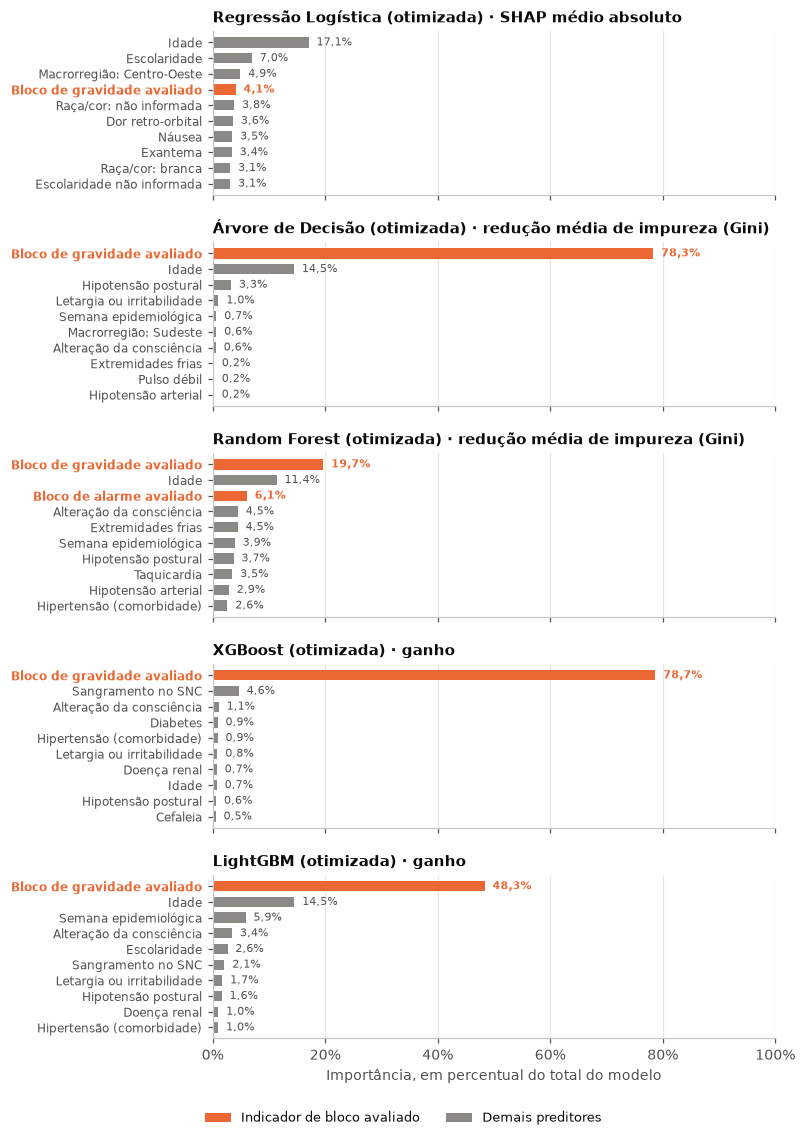

In [13]:
def painel(ax, rotulo, com_rotulo_x):
    d = IMP[(ROTULO_CONFIG[CONFIG_PRINCIPAL], rotulo)].head(TOP_N).iloc[::-1]
    destaque = (d['bloco'] == 'indicador de bloco').to_numpy()
    posicoes = np.arange(len(d))
    ax.barh(posicoes, d['importancia_pct'], height=0.66,
            color=np.where(destaque, COR_DESTAQUE, COR_DEMAIS))
    for pos, valor, marcado in zip(posicoes, d['importancia_pct'], destaque):
        ax.text(valor + 1.4, pos, pct_(valor, 1), va='center', ha='left', fontsize=7.5,
                color=COR_DESTAQUE if marcado else COR_TINTA,
                fontweight='bold' if marcado else 'normal')
    ax.set_yticks(posicoes)
    ax.set_yticklabels(d['rotulo'], fontsize=8)
    for marca, marcado in zip(ax.get_yticklabels(), destaque):
        if marcado:
            marca.set_fontweight('bold')
            marca.set_color(COR_DESTAQUE)
    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 20))
    ax.xaxis.set_major_formatter(eixo_pct())
    ax.set_ylim(-0.7, len(d) - 0.3)
    ax.grid(True, axis='x')
    ax.set_axisbelow(True)
    versao = IMP[(ROTULO_CONFIG[CONFIG_PRINCIPAL], rotulo)]['versao'].iloc[0]
    medida = IMP[(ROTULO_CONFIG[CONFIG_PRINCIPAL], rotulo)]['medida'].iloc[0]
    ax.set_title(f'{rotulo} ({versao}) · {medida}', loc='left', fontsize=9.5,
                 fontweight='bold', pad=6)
    ax.set_xlabel('Importância, em percentual do total do modelo' if com_rotulo_x else '')
    if not com_rotulo_x:
        ax.tick_params(axis='x', labelbottom=False)


LEGENDA = [Patch(facecolor=COR_DESTAQUE, label='Indicador de bloco avaliado'),
           Patch(facecolor=COR_DEMAIS, label='Demais preditores')]


def figura(rotulos, nome, altura_por_painel=2.05, largura=7.4):
    fig, eixos = plt.subplots(len(rotulos), 1, figsize=(largura,
                                                        altura_por_painel * len(rotulos)))
    eixos = np.atleast_1d(eixos)
    for i, (ax, rotulo) in enumerate(zip(eixos, rotulos)):
        painel(ax, rotulo, com_rotulo_x=(i == len(rotulos) - 1))
    fig.legend(handles=LEGENDA, loc='lower center', ncol=2, fontsize=8.5,
               bbox_to_anchor=(0.5, -0.012))
    fig.tight_layout(h_pad=1.4, rect=[0, 0.022, 1, 1])
    salvar_fig(fig, nome)
    plt.show()


figura(list(ALGORITMOS.values()), 'importancia_cinco_paineis.png')

Versão reduzida da figura, com Logistic Regression, Random Forest e XGBoost, para o caso de a de cinco painéis não caber no formato da revista.

[figura] analysis/plots/importancia/importancia_tres_paineis.png


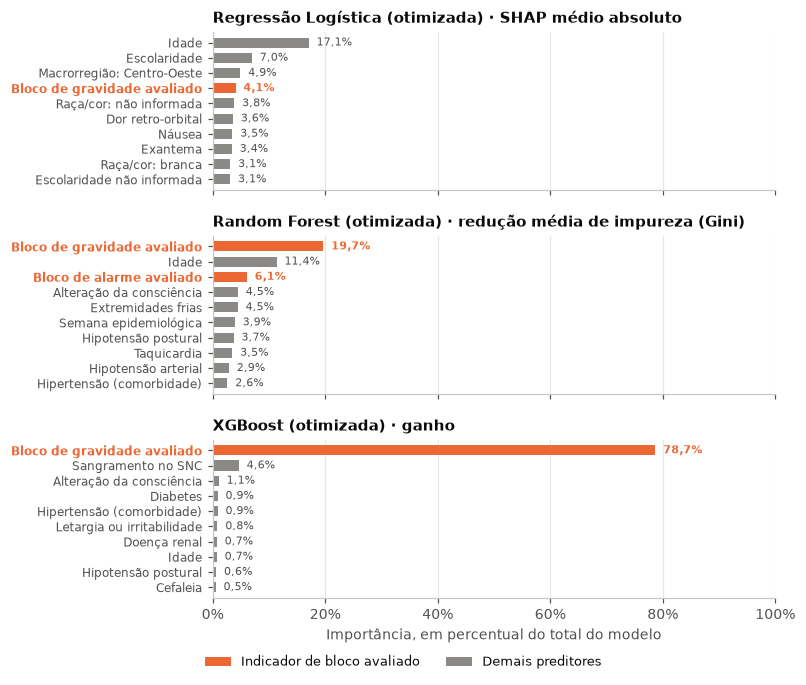

In [14]:
figura(['Regressão Logística', 'Random Forest', 'XGBoost'],
       'importancia_tres_paineis.png')

Números citados nas conclusões.

In [15]:
cor = ROTULO_CONFIG[CONFIG_PRINCIPAL]
for rotulo in ALGORITMOS.values():
    d = IMP[(cor, rotulo)]
    g = d[d['variavel'] == 'bloco_gravidade_avaliado'].iloc[0]
    a = d[d['variavel'] == 'bloco_alarme_avaliado'].iloc[0]
    primeira = d.iloc[0]
    print(f'{rotulo:22s} 1ª={primeira["rotulo"]} {primeira["importancia_pct"]:.1f}% | '
          f'gravidade pos {int(g["posicao"])} {g["importancia_pct"]:.1f}% | '
          f'alarme pos {int(a["posicao"])} {a["importancia_pct"]:.2f}% | '
          f'top10 soma {d.head(TOP_N)["importancia_pct"].sum():.1f}%')

print()
for rotulo in ALGORITMOS.values():
    d = df_comparacao[df_comparacao['algoritmo'] == rotulo]
    rho = float(df_spearman[df_spearman['algoritmo'] == rotulo]['spearman_rho'].iloc[0])
    perm = d[d['situacao'] == 'permanece']
    print(f'{rotulo:22s} rho={rho:.3f} | trocas={int((d["situacao"] == "entra").sum())} | '
          f'maior queda={perm["mudanca_posicao"].min():.0f} | '
          f'maior subida={perm["mudanca_posicao"].max():.0f}')

print()
for variavel in ['GRAV_EXTRE', 'GRAV_CONSC']:
    for rotulo in ALGORITMOS.values():
        ant = IMP[(ROTULO_CONFIG[CONFIG_COMPARACAO], rotulo)].set_index('variavel')
        d = IMP[(cor, rotulo)].set_index('variavel')
        if variavel in ant.index:
            print(f'{rotular(variavel):24s} {rotulo:22s} '
                  f'{ant.loc[variavel, "importancia_pct"]:6.2f}% (pos '
                  f'{int(ant.loc[variavel, "posicao"])}) -> '
                  f'{d.loc[variavel, "importancia_pct"]:6.2f}% (pos '
                  f'{int(d.loc[variavel, "posicao"])})')
    print()

maior_or = df_or_top.sort_values('razao_de_chances', ascending=False).iloc[0]
print(f'Maior OR: {maior_or["rotulo"]} {maior_or["razao_de_chances"]:.2f} '
      f'[{maior_or["ic95_inferior"]:.2f}; {maior_or["ic95_superior"]:.2f}], '
      f'SHAP {maior_or["importancia_shap_pct"]:.2f}% na posição {int(maior_or["posicao_shap"])}')
primeira_shap = df_or_top.iloc[0]
print(f'1ª SHAP: {primeira_shap["rotulo"]} {primeira_shap["importancia_shap_pct"]:.2f}%, '
      f'OR {primeira_shap["razao_de_chances"]:.2f} '
      f'[{primeira_shap["ic95_inferior"]:.2f}; {primeira_shap["ic95_superior"]:.2f}]')
print(f'IC inclui 1: '
      f'{df_or_top[df_or_top["ic95_inclui_1"] == "sim"]["rotulo"].tolist()}')

print()
for _, r in df_blocos[df_blocos['entre_as_dez_primeiras'] == 'não'].iterrows():
    print(f'{r["algoritmo"]:22s} {r["rotulo"]}: pos {int(r["posicao"])} de '
          f'{int(r["n_variaveis"])}, {r["importancia_pct"]:.2f}%, '
          f'{int(r["variaveis_com_mesma_importancia"])} empatadas no valor')

print()
for rotulo in ALGORITMOS.values():
    contas = {}
    for nome, cfg in (('antiga', ROTULO_CONFIG[CONFIG_COMPARACAO]),
                      ('corrigida', ROTULO_CONFIG[CONFIG_PRINCIPAL])):
        d = IMP[(cfg, rotulo)].head(TOP_N)
        contas[nome] = (int((d['bloco'] == 'manifestação grave').sum()),
                        round(float(d[d['bloco'] == 'manifestação grave']
                                    ['importancia_pct'].sum()), 1))
    print(f'{rotulo:22s} manifestações graves no top 10: '
          f'{contas["antiga"][0]} ({contas["antiga"][1]}%) -> '
          f'{contas["corrigida"][0]} ({contas["corrigida"][1]}%)')

Regressão Logística    1ª=Idade 17.1% | gravidade pos 4 4.1% | alarme pos 51 0.16% | top10 soma 53.6%
Árvore de Decisão      1ª=Bloco de gravidade avaliado 78.3% | gravidade pos 1 78.3% | alarme pos 70 0.00% | top10 soma 99.6%
Random Forest          1ª=Bloco de gravidade avaliado 19.7% | gravidade pos 1 19.7% | alarme pos 3 6.07% | top10 soma 62.7%
XGBoost                1ª=Bloco de gravidade avaliado 78.7% | gravidade pos 1 78.7% | alarme pos 70 0.00% | top10 soma 89.6%
LightGBM               1ª=Bloco de gravidade avaliado 48.3% | gravidade pos 1 48.3% | alarme pos 65 0.01% | top10 soma 82.2%

Regressão Logística    rho=0.904 | trocas=5 | maior queda=-6 | maior subida=0
Árvore de Decisão      rho=0.640 | trocas=4 | maior queda=-7 | maior subida=5
Random Forest          rho=0.985 | trocas=3 | maior queda=-2 | maior subida=0
XGBoost                rho=0.296 | trocas=7 | maior queda=-5 | maior subida=1
LightGBM               rho=0.600 | trocas=5 | maior queda=-2 | maior subida=4

Extremi

## Conclusões

- As medidas de importância não são comparáveis entre famílias em valor absoluto: redução média de impureza com critério Gini na Decision Tree e no Random Forest, ganho no XGBoost e no LightGBM, e SHAP médio absoluto em forma fechada na Logistic Regression.
  Todas são normalizadas para somar 100% dentro de cada modelo, e é essa normalização que torna as posições comparáveis.

- O indicador de bloco de gravidade avaliado é a primeira variável em quatro dos cinco modelos: 78,7% no XGBoost, 78,3% na Decision Tree, 48,3% no LightGBM e 19,7% no Random Forest.
  Na Logistic Regression fica em quarto, com 4,1%.

- O indicador de bloco de alarme avaliado só entra entre as dez primeiras no Random Forest, em terceiro, com 6,1%.
  Nos demais fica em 51ª de 71 na Logistic Regression, com 0,2%; em 65ª de 70 no LightGBM, com 0,01%; e com importância nula na Decision Tree e no XGBoost, em 70ª de 70, em variáveis que nunca entraram em corte.

- A idade é a única variável não indicadora presente entre as dez primeiras dos cinco modelos: 17,1% na Logistic Regression, 14,5% na Decision Tree, 14,5% no LightGBM, 11,4% no Random Forest e 0,7% no XGBoost.

- A concentração da importância nas dez primeiras variáveis vai de 53,6% na Logistic Regression e 62,7% no Random Forest a 82,2% no LightGBM, 89,6% no XGBoost e 99,6% na Decision Tree.

- O eixo geográfico sobe nos cinco modelos ao passar da UF ordinal para a macrorregião em one-hot, somada a importância das colunas de cada variável da ficha.
  Na Logistic Regression vai de 7ª de 51 com 3,4% para 2ª de 53 com 12,7%; no XGBoost, de 26ª com 0,8% para 3ª com 1,5%; na Decision Tree mantém a 5ª, com a importância caindo de 3,2% para 0,7%; no Random Forest cai de 5ª para 10ª, de 5,6% para 3,3%; e no LightGBM, de 4ª para 6ª, de 5,2% para 2,4%.

- A escolaridade, somando a escala ordinal e as indicadoras de não se aplica e de ausente, sobe em quatro dos cinco modelos: de 34ª para 3ª na Logistic Regression, com a importância indo de 0,5% para 10,7%; de 39ª para 12ª no XGBoost; de 11ª para 9ª no Random Forest; e de 9ª para 5ª no LightGBM.
  A exceção é a Decision Tree, onde cai de 14ª para 27ª.

- Entre as colunas que declaram ausente de uma demográfica, apenas duas entram entre as dez primeiras em algum modelo, e ambas na Logistic Regression: raça/cor não informada em 5ª com 3,8%, sobre 12,5% de ausência no treino, e escolaridade não informada em 10ª com 3,1%, sobre 42,3% de ausência.
  Gestação não informada e sexo não informado não entram nas dez primeiras de nenhum modelo.

- A concordância entre os dois ranqueamentos, por correlação de Spearman sobre as variáveis comuns, é de 0,985 no Random Forest e 0,904 na Logistic Regression, e cai para 0,640 na Decision Tree, 0,600 no LightGBM e 0,296 no XGBoost.
  O valor p fica abaixo de 0,001 em quatro modelos e em 0,041 no XGBoost.

- Na Decision Tree a correlação é calculada sobre um conjunto com muitos empates: das 59 variáveis comuns, 20 têm importância nula na configuração original e 47 na final.

- Extremidades frias era a primeira variável em três modelos na configuração original, com 38,9% na Decision Tree, 25,3% no LightGBM e 22,6% no XGBoost.
  Na final cai para 8ª com 0,2% na Decision Tree, 40ª com 0,3% no LightGBM e 38ª com 0,2% no XGBoost.

- Alteração da consciência permanece entre as dez primeiras dos modelos de árvore nas duas configurações, com a importância caindo de 17,8% para 0,6% na Decision Tree, de 12,1% para 3,4% no LightGBM, de 11,2% para 1,1% no XGBoost e de 6,6% para 4,5% no Random Forest.

- O número de manifestações graves entre as dez primeiras cai de 7 para 2 no XGBoost, de 6 para 4 no Random Forest, de 5 para 2 no LightGBM e de 5 para 4 na Decision Tree.
  A queda em importância somada é maior que a queda em contagem: na Decision Tree vai de 63,5% para 1,2% e no XGBoost de 55,2% para 5,7%.
  Na Logistic Regression nenhuma manifestação grave entra nas dez primeiras, nas duas configurações.

- Na Logistic Regression da configuração final a maior razão de chances é a do indicador de bloco de gravidade avaliado, 25,64 [19,01; 34,57], que ocupa apenas a quarta posição em importância SHAP, com 4,1%.
  A ordem por razão de chances e a ordem por SHAP não coincidem: a idade é primeira em SHAP, com 17,1%, e segunda em razão de chances, com 2,37 [2,16; 2,61].

- Dois intervalos de confiança incluem 1: raça/cor branca, 0,76 [0,55; 1,05], e o indicador de bloco de alarme avaliado, 0,98 [0,74; 1,30].
  Os intervalos são aproximados, pelas razões registradas na Parte 3.